In [1]:
# aperiodic: uses_preview_data

# Alpha Discovery

A structured, end-to-end alpha-discovery notebook. The research logic is broken
into discrete, documented stages so each part of the pipeline can be examined on
its own.

**What this notebook covers**

- converting raw microstructure metrics into scale-free, bounded signals
- a systematic search over the feature and parameter space, scoring each candidate
  on a transaction-cost-aware backtest
- diagnostics that distinguish a robust edge from parameter-specific overfitting
- a standalone snippet for reproducing the selected configuration out-of-sample

The notebook runs end to end on preview data.

### The pipeline

The workflow spans three phases — **construction**, **search**, and
**validation** — across six steps. Run the cell below for the color-coded
roadmap; each step that follows maps to one node.

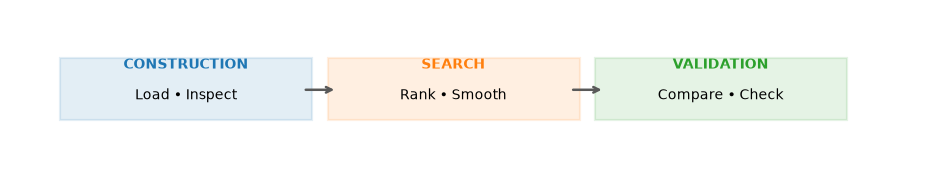

In [2]:
import matplotlib.pyplot as plt


def pipeline_diagram() -> None:
    phases = [
        ("Construction", "tab:blue", ["Load", "Inspect"]),
        ("Search", "tab:orange", ["Rank", "Smooth"]),
        ("Validation", "tab:green", ["Compare", "Check"]),
    ]

    fig, ax = plt.subplots(figsize=(12, 2.2))
    ax.set_xlim(0, 12)
    ax.set_ylim(0, 3)
    ax.axis("off")

    x = 0.65
    for phase_name, color, steps in phases:
        ax.add_patch(
            plt.Rectangle(
                (x, 1.05),
                3.25,
                1.1,
                facecolor=color,
                alpha=0.12,
                edgecolor=color,
                linewidth=1.6,
            )
        )
        ax.text(
            x + 1.62,
            2.02,
            phase_name.upper(),
            ha="center",
            va="center",
            fontsize=10,
            fontweight="bold",
            color=color,
        )
        ax.text(x + 1.62, 1.48, " • ".join(steps), ha="center", va="center", fontsize=10)
        x += 3.45

    for arrow_x in [4.0, 7.45]:
        ax.annotate(
            "",
            xy=(arrow_x + 0.22, 1.58),
            xytext=(arrow_x - 0.22, 1.58),
            arrowprops=dict(arrowstyle="->", lw=1.8, color="0.35"),
        )

pipeline_diagram()

**Using this notebook.** Run the two setup cells (configuration, then the helper
import), then proceed through Steps 1–6 in order. Each step pairs a brief rationale
with a single code cell. The closing section provides a standalone snippet for
reproducing the selected configuration.

---
## Setup — Configuration

All parameters for the study are consolidated here: the instrument and sample
period, the metric families to retrieve, and the two search dimensions. Edit this
cell and re-run; every downstream step reads from it.

- **`rank_windows`** — look-back length for the rolling percentile-rank transform
  (longer windows produce slower, more stable signals).
- **`smooth_windows`** — moving-average lengths applied to the ranked signal;
  `None` leaves it unsmoothed. This is the second search dimension.
- **`cost_bps`** — one-way transaction cost, in basis points, applied by the backtest.

In [3]:
import datetime
import os
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

API_KEY = "..."  # Set via APERIODIC_API_KEY env var or .env file
if API_KEY == "...":
    API_KEY = os.getenv("APERIODIC_API_KEY", "...")
if API_KEY == "...":
    raise RuntimeError("Set APERIODIC_API_KEY in the environment or in .env.")


@dataclass(frozen=True)
class AlphaDiscoveryConfig:
    """All parameters for the alpha-discovery notebook in one place."""

    api_key: str
    symbol: str
    exchange: str
    interval: str
    timestamp: str
    start_date: datetime.date
    end_date: datetime.date
    metrics: list[tuple[str, str]]
    rank_windows: list[int]
    smooth_windows: list[int | None]
    cost_bps: float

config = AlphaDiscoveryConfig(
    api_key=API_KEY,
    symbol="perpetual-BTC-USDT:USDT",
    exchange="binance-futures",
    interval="5m",
    timestamp="exchange",  # local timestamp or "true"
    start_date=datetime.date(2025, 5, 1),
    end_date=datetime.date(2025, 5, 31),
    metrics=[
        ("basis", "derivative"),
        ("funding", "derivative"),
        ("open_interest", "derivative"),
        ("flow", "regular"),
        ("impact", "regular"),
        ("l1_imbalance", "regular"),
        ("l1_liquidity", "regular"),
        ("returns", "regular"),
        ("slippage", "regular"),
        ("trade_size", "regular"),
        ("updownticks", "regular"),
        ("run_structure", "regular"),
        ("vtwap", "regular"),
        ("range", "regular"),
    ],
    rank_windows=[100, 300, 600, 1200, 2400],
    smooth_windows=[None, 10, 50, 100, 200, 400],
    cost_bps=1.0,
)

# Display parameters for the tables and plots below.
TOP_STRATEGY_COUNT = 10
TOP_PLOT_COUNT = 3

---
## Setup — Helper functions

The data retrieval, signal construction, search, and plotting routines are
defined below in this notebook so the analysis stays self-contained.

In [4]:
from aperiodic import get_derivative_metrics, get_metrics, get_ohlcv


def run_position_backtest(
    timestamps: pd.Series,
    position: np.ndarray,
    forward_return: np.ndarray,
    cost_bps_one_way: float = 0.0,
) -> tuple[pd.DataFrame, dict]:
    position = np.asarray(position, dtype=np.float64)
    forward_return = np.asarray(forward_return, dtype=np.float64)

    gross_pnl = position * forward_return
    turnover = np.abs(np.diff(position, prepend=0.0))
    cost = turnover * cost_bps_one_way / 1e4
    net_pnl = gross_pnl - cost
    equity = np.cumprod(1.0 + net_pnl)

    if equity.size == 0:
        bt_frame = pd.DataFrame({"timestamp": timestamps.to_numpy(), "equity_curve": equity})
        bt_summary = {
            "annualized_sharpe": 0.0,
            "net_return_pct": 0.0,
            "max_drawdown_pct": 0.0,
        }
        return bt_frame, bt_summary

    running_max = np.maximum.accumulate(equity)
    drawdowns = (equity - running_max) / running_max
    max_drawdown_pct = float(np.min(drawdowns)) * 100.0

    bars_per_year = 288 * 365
    mean_ret = float(np.mean(net_pnl))
    std_ret = float(np.std(net_pnl, ddof=1)) if len(net_pnl) > 1 else 1.0
    annualized_sharpe = (mean_ret / std_ret) * np.sqrt(bars_per_year) if std_ret > 0 else 0.0
    net_return_pct = (
        float((equity[-1] / equity[0] - 1.0) * 100.0) if len(equity) > 0 else 0.0
    )

    bt_frame = pd.DataFrame({"timestamp": timestamps.to_numpy(), "equity_curve": equity})
    bt_summary = {
        "annualized_sharpe": float(annualized_sharpe),
        "net_return_pct": net_return_pct,
        "max_drawdown_pct": max_drawdown_pct,
    }
    return bt_frame, bt_summary


def get_numeric_metric_frame(
    config: AlphaDiscoveryConfig, metric: str, kind: str
) -> pd.DataFrame | None:
    fetcher = get_derivative_metrics if kind == "derivative" else get_metrics
    raw_frame = fetcher(
        api_key=config.api_key,
        metric=metric,
        timestamp=config.timestamp,
        interval=config.interval,
        exchange=config.exchange,
        symbol=config.symbol,
        start_date=config.start_date,
        end_date=config.end_date,
        output="pandas",
        show_progress=True,
        preview=True,
    )

    frame = (
        raw_frame.to_pandas()
        if hasattr(raw_frame, "to_pandas")
        else pd.DataFrame(raw_frame)
    )
    if frame.empty or "time" not in frame.columns:
        print(f"Skipping {metric}: no rows returned.")
        return None

    numeric_cols = frame.select_dtypes(include=[np.number]).columns.tolist()
    if "time" in numeric_cols:
        numeric_cols.remove("time")

    if not numeric_cols:
        print(f"Skipping {metric}: no numeric columns returned.")
        return None

    return frame.sort_values("time").drop_duplicates(subset=["time"], keep="last")[
        ["time", *numeric_cols]
    ]


def build_panel(
    config: AlphaDiscoveryConfig,
) -> tuple[pd.DataFrame, list[str], dict[str, tuple[str, str]]]:
    raw_ohlcv = get_ohlcv(
        api_key=config.api_key,
        timestamp=config.timestamp,
        interval=config.interval,
        exchange=config.exchange,
        symbol=config.symbol,
        start_date=config.start_date,
        end_date=config.end_date,
        output="pandas",
        show_progress=True,
        preview=True,
    )

    panel = (
        raw_ohlcv.to_pandas()
        if hasattr(raw_ohlcv, "to_pandas")
        else pd.DataFrame(raw_ohlcv)
    )
    panel = panel.sort_values("time")[["time", "close"]]

    feature_sources: dict[str, tuple[str, str]] = {}
    for metric, kind in config.metrics:
        frame = get_numeric_metric_frame(config, metric, kind)
        if frame is None:
            continue

        feature_values = [col for col in frame.columns if col != "time"]
        if frame[feature_values].notna().sum().sum() == 0:
            print(f"Skipping {metric}: all feature values are null.")
            continue

        panel = panel.merge(frame, on="time", how="left")
        for col in feature_values:
            feature_sources[col] = (metric, kind)

    panel = panel.sort_values("time")
    feature_cols = [
        col
        for col in panel.columns
        if col not in {"time", "close"} and pd.api.types.is_numeric_dtype(panel[col])
    ]

    panel[feature_cols] = panel[feature_cols].ffill()
    panel["fwd_ret"] = panel["close"].pct_change().shift(-1)
    panel = panel.dropna(subset=["fwd_ret"])

    feature_sources = {col: feature_sources[col] for col in feature_cols if col in feature_sources}
    return panel, feature_cols, feature_sources


def summarize_panel(panel_df: pd.DataFrame, feature_cols: list[str]) -> pd.DataFrame:
    return pd.DataFrame(
        [
            {
                "feature": feature,
                "non_null_pct": float(panel_df[feature].notna().mean() * 100.0),
                "std": float(panel_df[feature].std()),
            }
            for feature in feature_cols[:10]
        ]
    )


def make_rank_signal(panel_df: pd.DataFrame, feature: str, window: int) -> np.ndarray:
    rank = panel_df[feature].rolling(window).rank(method="average")
    signal = ((rank - 1.0) / (window - 1)) * 2.0 - 1.0
    return signal.to_numpy().astype(np.float64)


def smooth_signal(signal: np.ndarray, window: int | None) -> np.ndarray:
    if window is None or pd.isna(window) or int(window) == 1:
        return signal.astype(np.float64, copy=True)

    return pd.Series(signal).rolling(int(window)).mean().to_numpy().astype(np.float64)


def evaluate_strategies(
    config: AlphaDiscoveryConfig, panel_df: pd.DataFrame, feature_cols: list[str]
) -> tuple[pd.DataFrame, np.ndarray]:
    forward_returns = panel_df["fwd_ret"].to_numpy().astype(np.float64)
    results: list[dict[str, float | int | str | None]] = []

    for feature in feature_cols:
        for rank_window in config.rank_windows:
            raw_signal = make_rank_signal(panel_df, feature, rank_window)

            for smooth_window in config.smooth_windows:
                signal = smooth_signal(raw_signal, smooth_window)
                mask = np.isfinite(signal) & np.isfinite(forward_returns)

                signal_valid = signal[mask]
                returns_valid = forward_returns[mask]
                if (
                    signal_valid.size < 2
                    or np.std(signal_valid) == 0.0
                    or np.std(returns_valid) == 0.0
                ):
                    continue

                fit_corr = float(np.corrcoef(signal_valid, returns_valid)[0, 1])
                if not np.isfinite(fit_corr):
                    continue

                direction = 1 if fit_corr >= 0 else -1
                _, bt_summary = run_position_backtest(
                    timestamps=panel_df.loc[mask, "time"],
                    position=np.nan_to_num(
                        np.clip(signal_valid * direction, -1.0, 1.0), nan=0.0
                    ),
                    forward_return=returns_valid,
                    cost_bps_one_way=config.cost_bps,
                )

                results.append(
                    {
                        "feature": feature,
                        "rank_window": rank_window,
                        "smooth_window": smooth_window,
                        "direction": direction,
                        "fit_corr": fit_corr,
                        "sharpe": bt_summary["annualized_sharpe"],
                        "return_pct": bt_summary["net_return_pct"],
                        "drawdown_pct": bt_summary["max_drawdown_pct"],
                    }
                )

    if not results:
        raise RuntimeError(
            "No valid feature/window combinations were produced. "
            "Check the fetched metric coverage for the selected date range."
        )

    results_df = pd.DataFrame(results).sort_values("sharpe", ascending=False)
    return results_df, forward_returns


def summarize_top_strategies(results_df: pd.DataFrame, top_n: int) -> pd.DataFrame:
    summary = results_df.head(top_n).copy()
    summary["smooth_window"] = summary["smooth_window"].map(
        lambda value: "None" if value is None or pd.isna(value) else int(value)
    )
    summary["direction"] = summary["direction"].map({1: "long", -1: "short"})
    return summary[
        [
            "feature",
            "rank_window",
            "smooth_window",
            "direction",
            "fit_corr",
            "sharpe",
            "return_pct",
            "drawdown_pct",
        ]
    ]


def build_strategy_artifacts(
    config: AlphaDiscoveryConfig,
    panel_df: pd.DataFrame,
    forward_returns: np.ndarray,
    row: pd.Series,
) -> tuple[np.ndarray, np.ndarray, pd.DataFrame, dict[str, float], np.ndarray]:
    raw_signal = make_rank_signal(
        panel_df, str(row["feature"]), int(row["rank_window"])
    )
    signal = smooth_signal(raw_signal, row["smooth_window"]) * int(row["direction"])
    mask = np.isfinite(signal) & np.isfinite(forward_returns)
    bt_frame, bt_summary = run_position_backtest(
        timestamps=panel_df.loc[mask, "time"],
        position=np.nan_to_num(np.clip(signal[mask], -1.0, 1.0), nan=0.0),
        forward_return=forward_returns[mask],
        cost_bps_one_way=config.cost_bps,
    )
    return raw_signal, signal, bt_frame, bt_summary, mask


def plot_strategy_overview(
    config: AlphaDiscoveryConfig,
    panel_df: pd.DataFrame,
    forward_returns: np.ndarray,
    row: pd.Series,
    title_prefix: str,
) -> tuple[np.ndarray, np.ndarray]:
    raw_signal, signal, bt_frame, _, mask = build_strategy_artifacts(
        config, panel_df, forward_returns, row
    )
    smooth_label = (
        "None"
        if row["smooth_window"] is None or pd.isna(row["smooth_window"])
        else int(row["smooth_window"])
    )

    fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
    axes[0].plot(panel_df["time"], raw_signal, linewidth=0.8, color="tab:orange")
    axes[0].axhline(0.0, color="black", linewidth=0.7, alpha=0.5)
    axes[0].set_title(f"{title_prefix} raw rank signal | {row['feature']}")
    axes[0].grid(alpha=0.2)

    axes[1].plot(panel_df["time"], signal, linewidth=0.9, color="tab:red")
    axes[1].axhline(0.0, color="black", linewidth=0.7, alpha=0.5)
    axes[1].set_title(
        f"{title_prefix} smoothed signal"
        f" | rank={int(row['rank_window'])}"
        f" | smooth={smooth_label}"
        f" | dir={int(row['direction'])}"
    )
    axes[1].grid(alpha=0.2)

    axes[2].plot(
        bt_frame["timestamp"],
        bt_frame["equity_curve"],
        linewidth=1.1,
        color="tab:green",
    )
    axes[2].set_title(
        f"{title_prefix} equity"
        f" | Sharpe={float(row['sharpe']):.3f}"
        f" | Ret={float(row['return_pct']):.3f}"
    )
    axes[2].grid(alpha=0.2)

    fig.tight_layout()
    plt.show()
    return signal, mask


def build_decile_summary(signal: np.ndarray, forward_returns: np.ndarray) -> pd.DataFrame:
    mask = np.isfinite(signal) & np.isfinite(forward_returns)
    signal_valid = signal[mask]
    returns_valid = forward_returns[mask]

    if signal_valid.size == 0:
        raise RuntimeError("Best strategy produced no valid observations for decile analysis.")

    order = np.argsort(signal_valid)
    deciles = np.empty(signal_valid.shape[0], dtype=np.int64)
    deciles[order] = (np.arange(signal_valid.shape[0]) * 10 // signal_valid.shape[0]) + 1

    return pd.DataFrame(
        [
            {
                "decile": decile,
                "count": int((decile_mask := deciles == decile).sum()),
                "mean_signal": float(np.nanmean(signal_valid[decile_mask])),
                "mean_fwd_ret": float(np.nanmean(returns_valid[decile_mask])),
            }
            for decile in range(1, 11)
        ]
    )

---
## Step 1 — Load and inspect the data

`build_panel` retrieves close price together with every numeric column from the
configured metric families, forward-fills sparse series, and constructs the
prediction target — the one-bar-ahead return (`fwd_ret`). We inspect the panel's
dimensions, a sample of rows, and per-feature coverage before building anything on
top of it.

In [5]:
panel, feature_cols, feature_sources = build_panel(config)
panel_summary = summarize_panel(panel, feature_cols)

print(f"Rows: {len(panel):,}")
print(f"Feature count: {len(feature_cols)}")
print(f"First features: {feature_cols[:12]}")
print(panel[["time", "close", "fwd_ret"]].head().to_markdown(index=False))

print("\nFeature coverage snapshot:")
print(panel_summary.to_markdown(index=False))

Rows: 8,927
Feature count: 153
First features: ['basis', 'basis_bps', 'mark_price_spread', 'mark_price_spread_bps', 'basis_mean', 'basis_bps_std', 'mark_price_spread_mean', 'mark_price_spread_bps_std', 'funding_rate', 'funding_rate_update_frequency', 'funding_rate_avg_update_interval', 'open_interest']
| time                |   close |      fwd_ret |
|:--------------------|--------:|-------------:|
| 2025-05-01 00:00:00 | 94190.3 |  0.000708141 |
| 2025-05-01 00:05:00 | 94257   | -0.00035435  |
| 2025-05-01 00:10:00 | 94223.6 | -0.000378886 |
| 2025-05-01 00:15:00 | 94187.9 |  0.000328068 |
| 2025-05-01 00:20:00 | 94218.8 |  0.000211211 |

Feature coverage snapshot:
| feature                       |   non_null_pct |          std |
|:------------------------------|---------------:|-------------:|
| basis                         |            100 | 10.3478      |
| basis_bps                     |            100 |  1.04411     |
| mark_price_spread             |            100 |  6.90846  

/var/folders/0d/k3d3nzn95672dr4h7p5pf60w0000gn/T/ipykernel_81491/3329177239.py:135: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  panel["fwd_ret"] = panel["close"].pct_change().shift(-1)


---
## Step 2 — Construct the signal

A raw feature is not directly tradeable: its level is non-stationary and its units
are arbitrary. Two transforms address this:

1. **Percentile rank.** Within a rolling window of `rank_window` bars, each value
   is replaced by its percentile rank and rescaled to `[-1, +1]`. A high value
   means "elevated relative to recent history," a low value the opposite — a
   scale-free measure that is comparable across features.
2. **Smoothing (optional).** A moving average of `smooth_window` bars applied to
   the ranked signal trades responsiveness for stability; `None` leaves it
   unsmoothed.

The position direction (long or short) is set by the sign of the in-sample
correlation between the signal and the one-bar-ahead return.

Because every feature is evaluated against every `(rank_window, smooth_window)`
pair, the search space has cardinality `features × rank_windows × smooth_windows`:

In [6]:
search_space = pd.DataFrame(
    [
        {
            "features": len(feature_cols),
            "rank_windows": len(config.rank_windows),
            "smooth_windows": len(config.smooth_windows),
            "total_combinations": (
                len(feature_cols) * len(config.rank_windows) * len(config.smooth_windows)
            ),
        }
    ]
)
print(search_space.to_markdown(index=False))

|   features |   rank_windows |   smooth_windows |   total_combinations |
|-----------:|---------------:|-----------------:|---------------------:|
|        153 |              5 |                6 |                 4590 |


---
## Step 3 — Search the parameter grid

`evaluate_strategies` traverses the full grid: for each combination it constructs
the signal, assigns a direction, and runs an identical transaction-cost-aware
position backtest. Each valid candidate is scored on annualized Sharpe, net
return, and maximum drawdown, then ranked by Sharpe.

In [7]:
results_df, forward_returns = evaluate_strategies(config, panel, feature_cols)
top_strategies = summarize_top_strategies(results_df, TOP_STRATEGY_COUNT)

print("Top strategies by Sharpe:")
print(top_strategies.to_markdown(index=False))

Top strategies by Sharpe:
| feature                    |   rank_window |   smooth_window | direction   |   fit_corr |   sharpe |   return_pct |   drawdown_pct |
|:---------------------------|--------------:|----------------:|:------------|-----------:|---------:|-------------:|---------------:|
| price_kurtosis             |          2400 |             200 | short       | -0.0301028 |  7.86532 |     0.688764 |      -0.135004 |
| volume_delta_notional      |          1200 |             100 | short       | -0.0336731 |  7.75412 |     1.15405  |      -0.240235 |
| volume_delta               |          1200 |             100 | short       | -0.0336114 |  7.72586 |     1.14757  |      -0.240183 |
| downtick_count_percentage  |          1200 |             200 | long        |  0.0245554 |  7.69932 |     3.2125   |      -0.798634 |
| taker_buy_sell_percentage  |          1200 |             400 | short       | -0.025119  |  7.54745 |     0.566899 |      -0.178828 |
| taker_buy_sell_ratio       

---
## Step 4 — Compare the leading candidates

The ranking identifies the strongest candidates; the plots characterize their
behavior. For the leading candidates we show the raw ranked signal, the smoothed
signal, and the resulting equity curve.

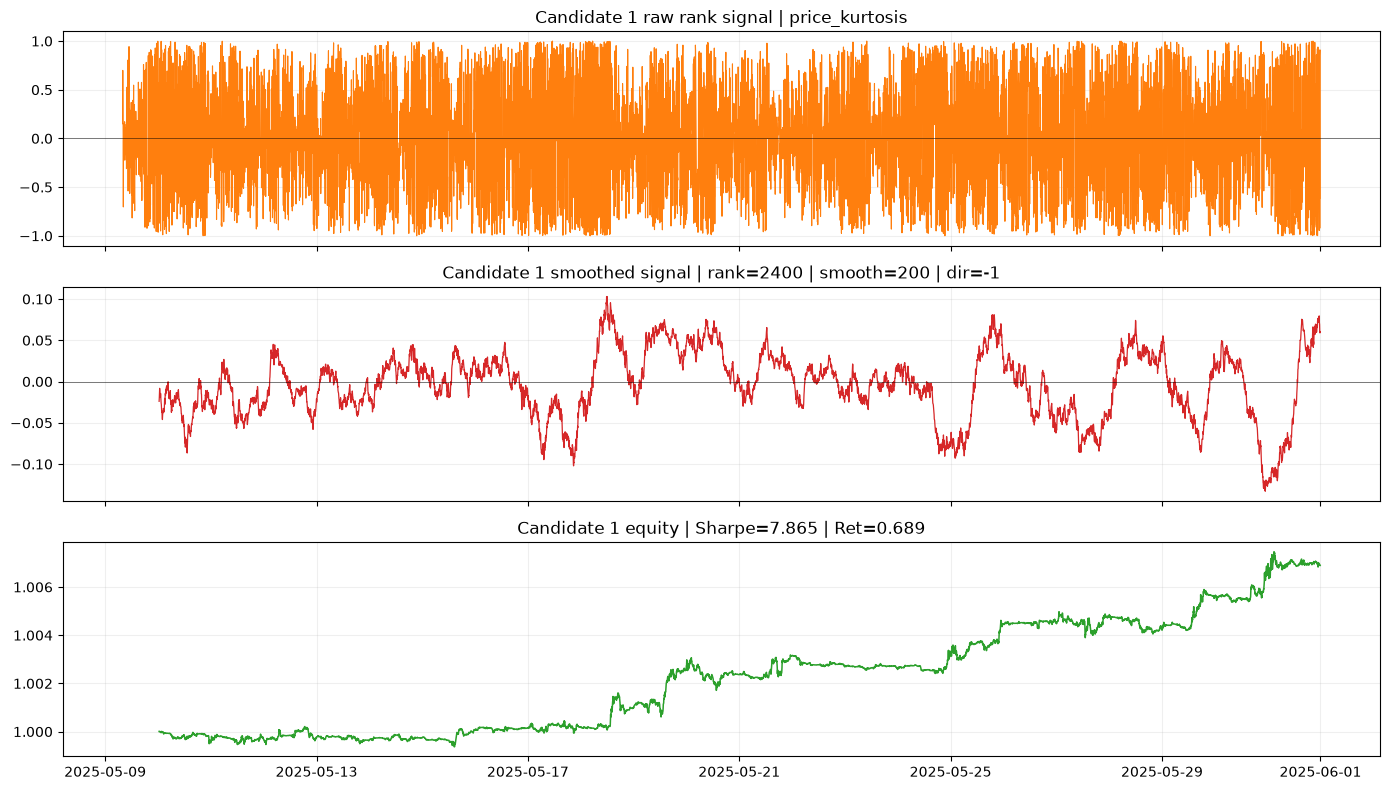

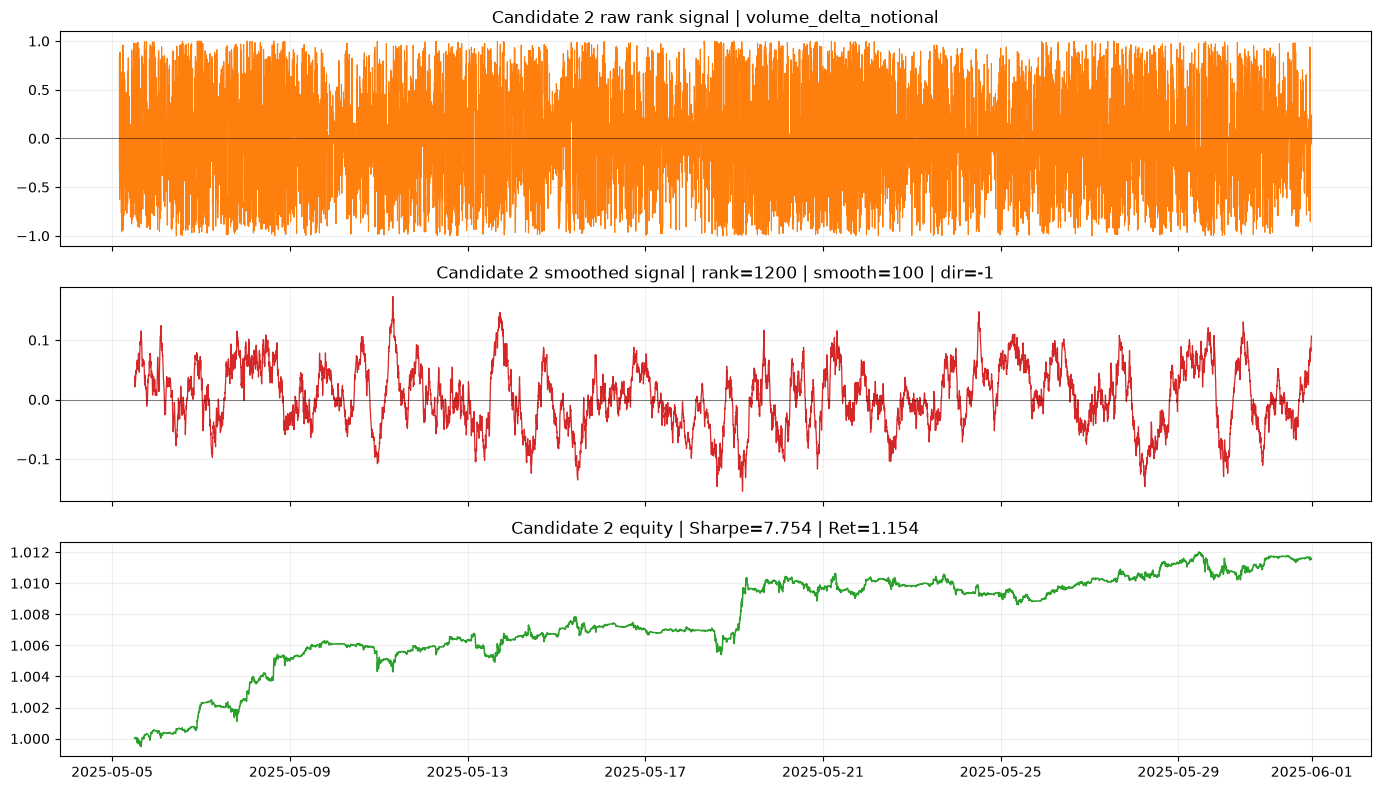

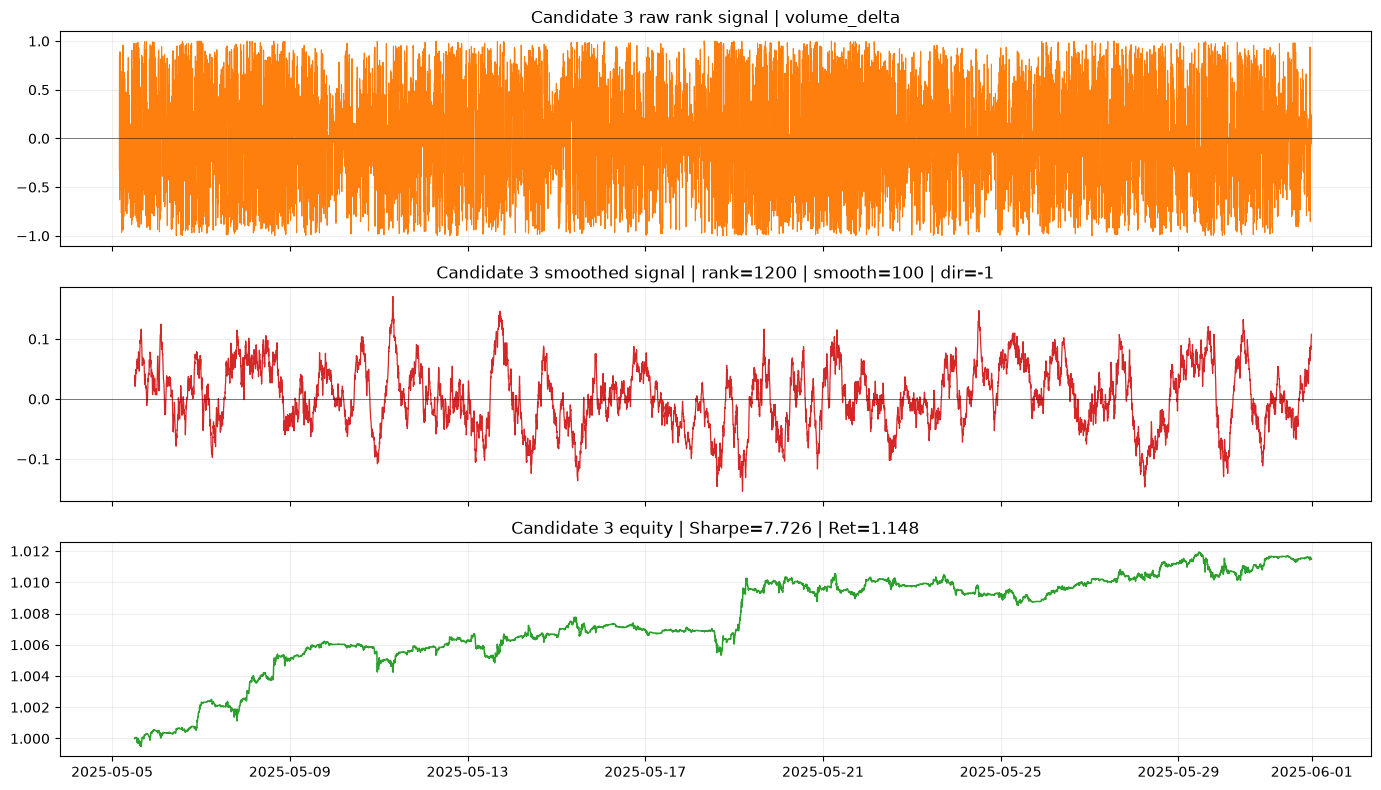

In [8]:
for plot_idx, (_, row) in enumerate(results_df.head(TOP_PLOT_COUNT).iterrows(), start=1):
    plot_strategy_overview(config, panel, forward_returns, row, f"Candidate {plot_idx}")

---
## Step 5 — Examine the best candidate

We isolate the highest-ranked candidate and inspect its signal and equity curve,
followed by a decile analysis: the signal is partitioned into ten buckets and the
mean one-bar-ahead return is computed for each. A monotonic progression across
deciles is stronger evidence of a genuine relationship than a single outlier
bucket driving the result.

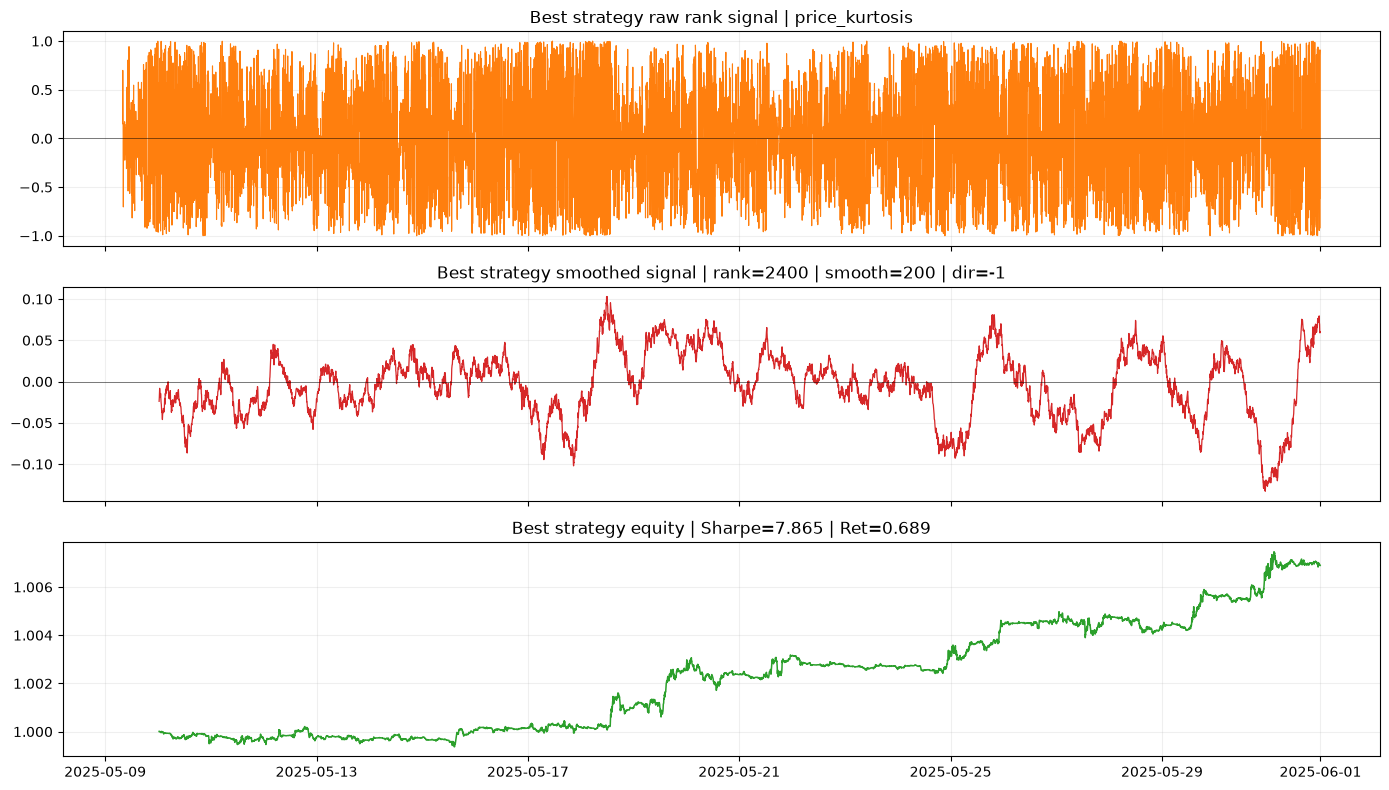

| feature        |   rank_window |   smooth_window | direction   |   fit_corr |   sharpe |   return_pct |   drawdown_pct |   valid_bars |
|:---------------|--------------:|----------------:|:------------|-----------:|---------:|-------------:|---------------:|-------------:|
| price_kurtosis |          2400 |             200 | short       | -0.0301028 |  7.86532 |     0.688764 |      -0.135004 |         6329 |


In [9]:
best = results_df.iloc[0]
best_signal, best_mask = plot_strategy_overview(
    config, panel, forward_returns, best, "Best strategy"
)

best_summary = pd.DataFrame(
    [
        {
            "feature": str(best["feature"]),
            "rank_window": int(best["rank_window"]),
            "smooth_window": (
                "None"
                if best["smooth_window"] is None or pd.isna(best["smooth_window"])
                else int(best["smooth_window"])
            ),
            "direction": "long" if int(best["direction"]) == 1 else "short",
            "fit_corr": float(best["fit_corr"]),
            "sharpe": float(best["sharpe"]),
            "return_pct": float(best["return_pct"]),
            "drawdown_pct": float(best["drawdown_pct"]),
            "valid_bars": int(best_mask.sum()),
        }
    ]
)
print(best_summary.to_markdown(index=False))

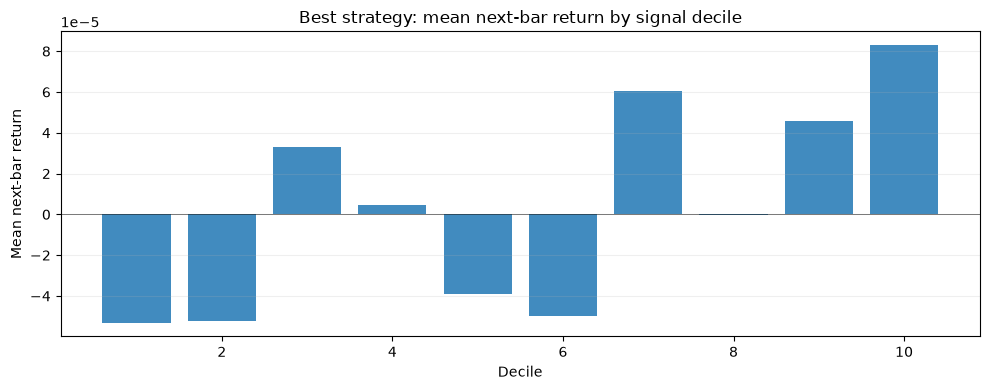

|   decile |   count |   mean_signal |   mean_fwd_ret |
|---------:|--------:|--------------:|---------------:|
|        1 |     633 |   -0.0814392  |   -5.30763e-05 |
|        2 |     633 |   -0.0460306  |   -5.2215e-05  |
|        3 |     633 |   -0.0291943  |    3.30655e-05 |
|        4 |     633 |   -0.0178473  |    4.4612e-06  |
|        5 |     633 |   -0.00728716 |   -3.88128e-05 |
|        6 |     633 |    0.00315252 |   -4.99037e-05 |
|        7 |     633 |    0.0127794  |    6.04372e-05 |
|        8 |     633 |    0.0226082  |   -3.00854e-07 |
|        9 |     633 |    0.0369392  |    4.58241e-05 |
|       10 |     632 |    0.0603378  |    8.29295e-05 |


In [10]:
deciles_df = build_decile_summary(best_signal, forward_returns)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(deciles_df["decile"], deciles_df["mean_fwd_ret"], color="tab:blue", alpha=0.85)
ax.axhline(0.0, color="black", linewidth=0.7, alpha=0.5)
ax.set_title("Best strategy: mean next-bar return by signal decile")
ax.set_xlabel("Decile")
ax.set_ylabel("Mean next-bar return")
ax.grid(alpha=0.2, axis="y")
fig.tight_layout()
plt.show()

print(deciles_df.to_markdown(index=False))

---
## Step 6 — Robustness check

Is the measured edge genuine, or an artifact of a single parameter combination?
The heatmap shows the top feature's Sharpe across the full `rank_window ×
smooth_window` grid. An isolated high-Sharpe cell among weak neighbors indicates
overfitting; a contiguous high-Sharpe region indicates the edge degrades
gracefully under parameter perturbation, which is characteristic of a robust
signal.

> **Scope.** This assesses robustness to parameter selection in-sample. It is a
> diagnostic, not a substitute for out-of-sample validation — see *Next steps*.

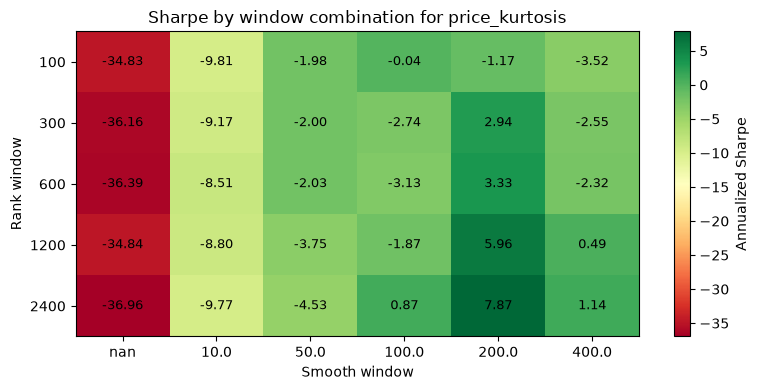

In [11]:
best_feature_results = results_df.loc[
    results_df["feature"] == best["feature"],
    ["rank_window", "smooth_window", "sharpe"],
].copy()
heatmap = best_feature_results.pivot(
    index="rank_window", columns="smooth_window", values="sharpe"
).sort_index()
heatmap = heatmap.rename(columns={None: "None"})

fig, ax = plt.subplots(figsize=(8, 4))
image = ax.imshow(heatmap.to_numpy(), aspect="auto", cmap="RdYlGn")
ax.set_title(f"Sharpe by window combination for {best['feature']}")
ax.set_xlabel("Smooth window")
ax.set_ylabel("Rank window")
ax.set_xticks(np.arange(len(heatmap.columns)), labels=heatmap.columns)
ax.set_yticks(np.arange(len(heatmap.index)), labels=heatmap.index)

for row_idx, row_values in enumerate(heatmap.to_numpy()):
    for col_idx, value in enumerate(row_values):
        ax.text(col_idx, row_idx, f"{value:.2f}", ha="center", va="center", fontsize=9)

fig.colorbar(image, ax=ax, label="Annualized Sharpe")
fig.tight_layout()
plt.show()

In [12]:
top_feature_summary = (
    results_df.groupby("feature", as_index=False)["sharpe"]
    .max()
    .sort_values("sharpe", ascending=False)
    .head(10)
)
print("Top features by best Sharpe:")
print(top_feature_summary.to_markdown(index=False))

Top features by best Sharpe:
| feature                    |   sharpe |
|:---------------------------|---------:|
| price_kurtosis             |  7.86532 |
| volume_delta_notional      |  7.75412 |
| volume_delta               |  7.72586 |
| downtick_count_percentage  |  7.69932 |
| taker_buy_sell_percentage  |  7.54745 |
| taker_buy_sell_ratio       |  7.5474  |
| downtick_volume_percentage |  7.43528 |
| unchanged_count_percentage |  7.1726  |
| bid_ask_ratio_avg          |  6.77595 |
| trade_amount_std           |  6.69955 |


---
## Recap

This notebook executed the complete workflow:

- **Loaded** price and microstructure features and constructed a one-bar-ahead
  return target.
- **Constructed** scale-free ranked signals, with optional smoothing.
- **Searched** the full feature × window grid, scoring every candidate on a
  cost-aware backtest.
- **Validated** the leading candidates via equity curve, decile monotonicity, and
  parameter-robustness diagnostics.

Note that smoothing constitutes a second search dimension: a feature can rank
highly either because its raw ranked signal is predictive or because a slower
variant is cleaner.

---
## Next steps

The natural follow-up is **out-of-sample validation**: re-run the selected
configuration on a later period, a different instrument, or another venue. An edge
that persists out-of-sample warrants further study.

The cell below prints a **standalone snippet**, pre-filled with this run's selected
configuration. It depends only on `aperiodic`, `numpy`, and `pandas` — no code from
this repository — so it can be copied into any environment and run as-is. It
defaults to the in-sample window on preview data and reports the configuration's
annualized Sharpe, net return, and maximum drawdown; change the dates (and set
`PREVIEW = False` with a full API key) to validate out-of-sample.

In [13]:
best_feature = str(best["feature"])
best_metric, best_kind = feature_sources.get(best_feature, (best_feature, "regular"))
best_rank = int(best["rank_window"])
best_smooth = (
    None
    if best["smooth_window"] is None or pd.isna(best["smooth_window"])
    else int(best["smooth_window"])
)
fetch_fn = "get_derivative_metrics" if best_kind == "derivative" else "get_metrics"

snippet = f'''# Standalone reproduction of the selected configuration.
# Dependencies: aperiodic, numpy, pandas.
import datetime

import numpy as np
import pandas as pd
from aperiodic import get_ohlcv, {fetch_fn}

API_KEY = "YOUR_KEY"
SYMBOL, EXCHANGE = "{config.symbol}", "{config.exchange}"
INTERVAL, TIMESTAMP = "{config.interval}", "{config.timestamp}"
START = datetime.date.fromisoformat("{config.start_date.isoformat()}")
END = datetime.date.fromisoformat("{config.end_date.isoformat()}")
PREVIEW = True  # set False with a full API key (and shift START/END) for out-of-sample

FEATURE = "{best_feature}"          # selected feature column
METRIC = "{best_metric}"            # its source metric family
RANK_WINDOW = {best_rank}
SMOOTH_WINDOW = {best_smooth}        # None disables smoothing
DIRECTION = {int(best["direction"])}            # +1 long, -1 short
COST_BPS = {config.cost_bps}

# 1. Retrieve close price and the source metric, de-duplicate, and align on time.
price = get_ohlcv(api_key=API_KEY, symbol=SYMBOL, exchange=EXCHANGE, interval=INTERVAL,
                  timestamp=TIMESTAMP, start_date=START, end_date=END,
                  output="pandas", preview=PREVIEW)
price = price.to_pandas() if hasattr(price, "to_pandas") else pd.DataFrame(price)
price = price.sort_values("time")[["time", "close"]]

metric = {fetch_fn}(api_key=API_KEY, metric=METRIC, symbol=SYMBOL, exchange=EXCHANGE,
                  interval=INTERVAL, timestamp=TIMESTAMP, start_date=START, end_date=END,
                  output="pandas", preview=PREVIEW)
metric = metric.to_pandas() if hasattr(metric, "to_pandas") else pd.DataFrame(metric)
metric = metric.sort_values("time").drop_duplicates(subset=["time"], keep="last")

panel = price.merge(metric[["time", FEATURE]], on="time", how="left").sort_values("time")
panel[FEATURE] = panel[FEATURE].ffill()
panel["fwd_ret"] = panel["close"].pct_change().shift(-1)
panel = panel.dropna(subset=["fwd_ret"])

# 2. Rebuild the ranked (and optionally smoothed) signal, then form the position.
rank = panel[FEATURE].rolling(RANK_WINDOW).rank(method="average")
signal = ((rank - 1.0) / (RANK_WINDOW - 1)) * 2.0 - 1.0
if SMOOTH_WINDOW:
    signal = signal.rolling(SMOOTH_WINDOW).mean()
position = (signal * DIRECTION).clip(-1.0, 1.0)

# 3. Transaction-cost-aware position backtest.
fwd_ret = panel["fwd_ret"].to_numpy()
pos = position.to_numpy()
valid = np.isfinite(pos) & np.isfinite(fwd_ret)
pos, fwd_ret = pos[valid], fwd_ret[valid]
turnover = np.abs(np.diff(pos, prepend=0.0))
net = pos * fwd_ret - turnover * COST_BPS / 1e4
equity = np.cumprod(1.0 + net)

bars_per_year = 288 * 365  # 5-minute bars
std = net.std(ddof=1)
sharpe = net.mean() / std * np.sqrt(bars_per_year) if std > 0 else 0.0
net_return_pct = (equity[-1] / equity[0] - 1.0) * 100.0
running_max = np.maximum.accumulate(equity)
max_drawdown_pct = ((equity - running_max) / running_max).min() * 100.0

print("feature =", FEATURE, "| rank =", RANK_WINDOW, "| smooth =", SMOOTH_WINDOW,
      "| direction =", DIRECTION)
print("annualized_sharpe = %.3f | net_return_pct = %.3f | max_drawdown_pct = %.3f"
      % (sharpe, net_return_pct, max_drawdown_pct))
'''

display(
    Markdown(
        "#### Standalone snippet — reproduce this configuration\n\n"
        "```python\n" + snippet + "\n```"
    )
)

print(
    "Selected configuration ·",
    f"feature={best_feature} · metric={best_metric} · rank={best_rank} · "
    f"smooth={best_smooth} · direction={'long' if int(best['direction']) == 1 else 'short'}",
)

#### Standalone snippet — reproduce this configuration

```python
# Standalone reproduction of the selected configuration.
# Dependencies: aperiodic, numpy, pandas.
import datetime

import numpy as np
import pandas as pd
from aperiodic import get_ohlcv, get_metrics

API_KEY = "YOUR_KEY"
SYMBOL, EXCHANGE = "perpetual-BTC-USDT:USDT", "binance-futures"
INTERVAL, TIMESTAMP = "5m", "exchange"
START = datetime.date.fromisoformat("2025-05-01")
END = datetime.date.fromisoformat("2025-05-31")
PREVIEW = True  # set False with a full API key (and shift START/END) for out-of-sample

FEATURE = "price_kurtosis"          # selected feature column
METRIC = "range"            # its source metric family
RANK_WINDOW = 2400
SMOOTH_WINDOW = 200        # None disables smoothing
DIRECTION = -1            # +1 long, -1 short
COST_BPS = 1.0

# 1. Retrieve close price and the source metric, de-duplicate, and align on time.
price = get_ohlcv(api_key=API_KEY, symbol=SYMBOL, exchange=EXCHANGE, interval=INTERVAL,
                  timestamp=TIMESTAMP, start_date=START, end_date=END,
                  output="pandas", preview=PREVIEW)
price = price.to_pandas() if hasattr(price, "to_pandas") else pd.DataFrame(price)
price = price.sort_values("time")[["time", "close"]]

metric = get_metrics(api_key=API_KEY, metric=METRIC, symbol=SYMBOL, exchange=EXCHANGE,
                  interval=INTERVAL, timestamp=TIMESTAMP, start_date=START, end_date=END,
                  output="pandas", preview=PREVIEW)
metric = metric.to_pandas() if hasattr(metric, "to_pandas") else pd.DataFrame(metric)
metric = metric.sort_values("time").drop_duplicates(subset=["time"], keep="last")

panel = price.merge(metric[["time", FEATURE]], on="time", how="left").sort_values("time")
panel[FEATURE] = panel[FEATURE].ffill()
panel["fwd_ret"] = panel["close"].pct_change().shift(-1)
panel = panel.dropna(subset=["fwd_ret"])

# 2. Rebuild the ranked (and optionally smoothed) signal, then form the position.
rank = panel[FEATURE].rolling(RANK_WINDOW).rank(method="average")
signal = ((rank - 1.0) / (RANK_WINDOW - 1)) * 2.0 - 1.0
if SMOOTH_WINDOW:
    signal = signal.rolling(SMOOTH_WINDOW).mean()
position = (signal * DIRECTION).clip(-1.0, 1.0)

# 3. Transaction-cost-aware position backtest.
fwd_ret = panel["fwd_ret"].to_numpy()
pos = position.to_numpy()
valid = np.isfinite(pos) & np.isfinite(fwd_ret)
pos, fwd_ret = pos[valid], fwd_ret[valid]
turnover = np.abs(np.diff(pos, prepend=0.0))
net = pos * fwd_ret - turnover * COST_BPS / 1e4
equity = np.cumprod(1.0 + net)

bars_per_year = 288 * 365  # 5-minute bars
std = net.std(ddof=1)
sharpe = net.mean() / std * np.sqrt(bars_per_year) if std > 0 else 0.0
net_return_pct = (equity[-1] / equity[0] - 1.0) * 100.0
running_max = np.maximum.accumulate(equity)
max_drawdown_pct = ((equity - running_max) / running_max).min() * 100.0

print("feature =", FEATURE, "| rank =", RANK_WINDOW, "| smooth =", SMOOTH_WINDOW,
      "| direction =", DIRECTION)
print("annualized_sharpe = %.3f | net_return_pct = %.3f | max_drawdown_pct = %.3f"
      % (sharpe, net_return_pct, max_drawdown_pct))

```

Selected configuration · feature=price_kurtosis · metric=range · rank=2400 · smooth=200 · direction=short
